## given isolated clusters of drifters, create contours of the watersheds and find the areas of the contours considering a spherical earth.


#### import and define clusters


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Polygon


In [2]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "watershed_ids").exists():
    PROJECT_DIR = Path("/home/codycruz/drifters_watersheds")

parquet_path = PROJECT_DIR / "undrogued_beach.parquet"
csv_path = PROJECT_DIR / "undrogued_beach.csv"

if parquet_path.exists():
    beach_undrogued = pd.read_parquet(
        parquet_path,
        columns=["id", "lat", "lon", "time_to_beach"],
    )
elif csv_path.exists():
    beach_undrogued = pd.read_csv(
        csv_path,
        usecols=["id", "lat", "lon", "time_to_beach"],
    )
else:
    raise FileNotFoundError(
        f"Could not find either {parquet_path.name} or {csv_path.name} in {PROJECT_DIR}"
    )

beach_undrogued.head()


,id,lat,lon,time_to_beach
0,101510,22.43137,120.45541,363600.0
1,101510,22.43232,120.45519,360000.0
2,101510,22.43020,120.45683,356400.0
3,101510,22.42962,120.45589,352800.0
4,101510,22.42837,120.45268,349200.0


In [3]:
watershed_order = [
    "N_Pacific",
    "W_Pacific",
    "SW_Pacific",
    "N_Indian",
    "W_Indian",
    "Mid_Atlantic",
    "NE_Atlantic",
    "NW_Atlantic",
    "Southern_Ocean_Australia",
    "Tasman_Sea",
    "W_Central_Pacific",
    "SW_Atlantic",
    "Southern_Ocean_S_America",
    "E_Central_Pacific",
]

id_dataframes = {
    name: PROJECT_DIR / "watershed_ids" / f"{name}_ids.csv"
    for name in watershed_order
}

missing_files = [path for path in id_dataframes.values() if not path.exists()]
if missing_files:
    missing_text = "\n".join(str(path) for path in missing_files)
    raise FileNotFoundError(f"Missing watershed ID files:\n{missing_text}")

loaded_ids = {name: pd.read_csv(path) for name, path in id_dataframes.items()}

pd.Series({name: len(df) for name, df in loaded_ids.items()}, name="trajectory_ids")


N_Pacific                   163
W_Pacific                   301
SW_Pacific                   88
N_Indian                     61
W_Indian                    240
Mid_Atlantic                102
NE_Atlantic                 303
NW_Atlantic                 265
Southern_Ocean_Australia     60
Tasman_Sea                   64
W_Central_Pacific            84
SW_Atlantic                 134
Southern_Ocean_S_America    147
E_Central_Pacific            42
Name: trajectory_ids, dtype: int64

In [4]:
id_lookup = pd.concat(
    [
        df[["id"]].dropna().astype({"id": int}).assign(watershed=name)
        for name, df in loaded_ids.items()
    ],
    ignore_index=True,
).drop_duplicates()

if id_lookup["id"].duplicated().any():
    duplicate_ids = id_lookup.loc[id_lookup["id"].duplicated(), "id"].tolist()
    raise ValueError(f"Duplicate IDs were assigned to multiple watersheds: {duplicate_ids[:10]}")

watershed_points = beach_undrogued[beach_undrogued["id"].isin(id_lookup["id"])].copy()
watershed_points = watershed_points.merge(id_lookup, on="id", how="inner")

grouped_watersheds = {
    name: group[["id", "lat", "lon", "time_to_beach"]].copy()
    for name, group in watershed_points.groupby("watershed", sort=False)
}

empty_watershed = pd.DataFrame(columns=["id", "lat", "lon", "time_to_beach"])
watersheds = {
    name: grouped_watersheds.get(name, empty_watershed).copy()
    for name in watershed_order
}

pd.DataFrame(
    {
        "points": [len(watersheds[name]) for name in watershed_order],
        "unique_ids": [watersheds[name]["id"].nunique() for name in watershed_order],
    },
    index=watershed_order,
)


,points,unique_ids
N_Pacific,840954,163
W_Pacific,1136147,301
SW_Pacific,542676,88
N_Indian,176576,61
W_Indian,2238242,240
Mid_Atlantic,277754,102
NE_Atlantic,1560872,303
NW_Atlantic,1851382,265
Southern_Ocean_Australia,699359,60
Tasman_Sea,590564,64


#### sort cluster trajectories into their time based groups using functions: 1 month, 3 months, 6 months, 1 year


In [5]:
TIME_WINDOWS = {
    "1 month": 2_629_800,
    "3 months": 7_776_000,
    "6 months": 15_638_400,
    "12 months": 31_536_000,
}
PERIOD_ORDER = ["12 months", "6 months", "3 months", "1 month"]
DISPLAY_LABELS = [name.replace("_", " ") for name in watershed_order]

n_lons, n_lats = 135, 85
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

def preprocess_data(df):
    cleaned = df.copy()
    cleaned["lat"] = pd.to_numeric(cleaned["lat"], errors="coerce")
    cleaned["lon"] = pd.to_numeric(cleaned["lon"], errors="coerce")
    cleaned["time_to_beach"] = pd.to_numeric(cleaned["time_to_beach"], errors="coerce")
    return cleaned.dropna(subset=["lat", "lon", "time_to_beach"])

def filter_to_window(cluster, max_seconds):
    return cluster.loc[cluster["time_to_beach"] <= max_seconds].copy()

def one_to_beach(cluster):
    return filter_to_window(cluster, TIME_WINDOWS["1 month"])

def three_to_beach(cluster):
    return filter_to_window(cluster, TIME_WINDOWS["3 months"])

def six_to_beach(cluster):
    return filter_to_window(cluster, TIME_WINDOWS["6 months"])

def year_to_beach(cluster):
    return filter_to_window(cluster, TIME_WINDOWS["12 months"])

def histogram_for_watershed(cluster, max_seconds):
    filtered = preprocess_data(filter_to_window(cluster, max_seconds))
    if filtered.empty:
        return np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

    heatmap_data, _, _ = np.histogram2d(
        filtered["lat"].values,
        filtered["lon"].values,
        bins=[lat_bins, lon_bins],
        density=False,
    )
    return heatmap_data


#### define the times to beach (1yr, 6m, 3m, 1m) and dataframe


In [6]:
AREA_PROJECTION_EPSG = 6933
REGION_CONTOUR_LEVEL = 100
TOTAL_OCEAN_AREA_KM2 = 361_132_000

def contour_area_from_segments(segments):
    total_area_m2 = 0.0

    for polygon_coords in segments:
        if len(polygon_coords) < 3:
            continue

        if not np.array_equal(polygon_coords[0], polygon_coords[-1]):
            polygon_coords = np.vstack([polygon_coords, polygon_coords[0]])

        polygon = Polygon(polygon_coords)
        if not polygon.is_valid:
            polygon = polygon.buffer(0)
        if polygon.is_empty:
            continue

        geometry = gpd.GeoDataFrame(geometry=[polygon], crs="EPSG:4326").to_crs(
            epsg=AREA_PROJECTION_EPSG
        )
        total_area_m2 += float(geometry.geometry.area.iloc[0])

    return total_area_m2 / 1_000_000

def contour_area_from_heatmap(heatmap_data, contour_level=REGION_CONTOUR_LEVEL):
    if float(np.nanmax(heatmap_data)) < contour_level:
        return 0.0

    fig, ax = plt.subplots(figsize=(10, 6))
    contour = ax.contour(
        lon_centers,
        lat_centers,
        heatmap_data,
        levels=[contour_level],
        colors="white",
    )
    plt.close(fig)

    if not contour.allsegs or not contour.allsegs[0]:
        return 0.0

    return contour_area_from_segments(contour.allsegs[0])

def plot_area_bars(area_results, title, color="skyblue"):
    values = [area_results[region] for region in watershed_order]

    plt.figure(figsize=(12, 6))
    plt.bar(DISPLAY_LABELS, values, color=color)
    plt.xlabel("Regions")
    plt.ylabel("Total Area (km²)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

histograms_by_period = {
    period_label: {
        region: histogram_for_watershed(cluster, TIME_WINDOWS[period_label])
        for region, cluster in watersheds.items()
    }
    for period_label in TIME_WINDOWS
}

area_results_by_period = {
    period_label: {
        region: contour_area_from_heatmap(heatmap)
        for region, heatmap in region_heatmaps.items()
    }
    for period_label, region_heatmaps in histograms_by_period.items()
}

area_table = pd.DataFrame(area_results_by_period).T[watershed_order]
area_table


,N_Pacific,W_Pacific,SW_Pacific,N_Indian,W_Indian,Mid_Atlantic,NE_Atlantic,NW_Atlantic,Southern_Ocean_Australia,Tasman_Sea,W_Central_Pacific,SW_Atlantic,Southern_Ocean_S_America,E_Central_Pacific
1 month,3.940888e+06,1.303512e+07,5.031020e+06,4.701193e+06,1.089382e+07,3.372058e+06,7.986847e+06,8.058438e+06,1.874649e+06,2.135502e+06,5.616032e+06,3.775511e+06,3.654901e+06,2.563776e+06
3 months,5.713419e+06,1.990657e+07,9.129997e+06,8.004968e+06,1.771336e+07,7.022087e+06,1.187321e+07,1.394455e+07,3.507243e+06,3.601799e+06,1.199751e+07,8.786065e+06,7.531939e+06,4.159086e+06
6 months,7.337620e+06,2.593484e+07,1.228513e+07,1.229459e+07,2.549321e+07,9.550324e+06,1.495013e+07,2.108361e+07,5.233999e+06,6.272112e+06,2.102678e+07,1.253000e+07,1.231659e+07,6.319715e+06
12 months,9.903546e+06,3.157978e+07,1.529358e+07,1.612997e+07,4.237324e+07,1.083636e+07,1.946678e+07,2.799849e+07,9.098060e+06,9.570979e+06,3.225756e+07,1.673610e+07,1.962123e+07,7.574176e+06


#### individual plots


12 months: 268,439,851 km²


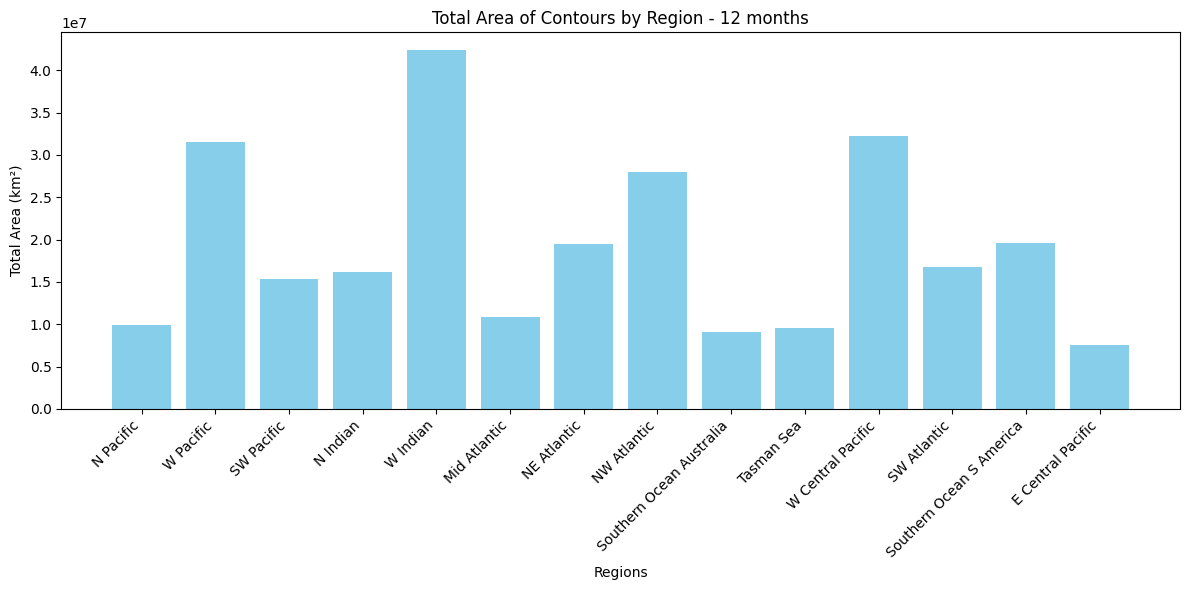

6 months: 192,628,654 km²


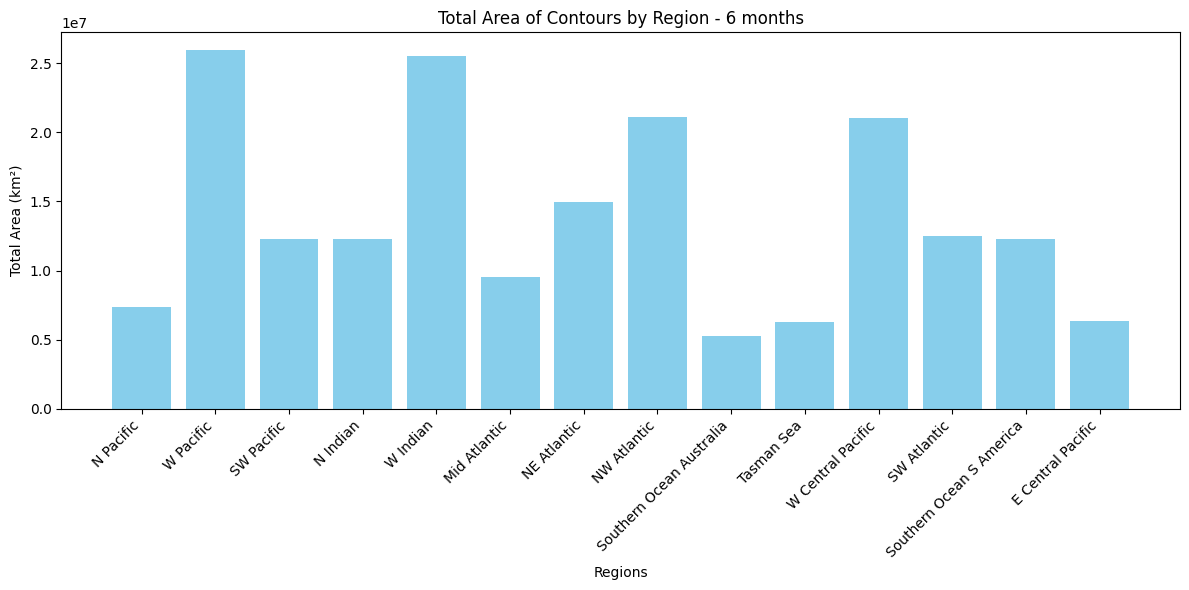

3 months: 132,891,795 km²


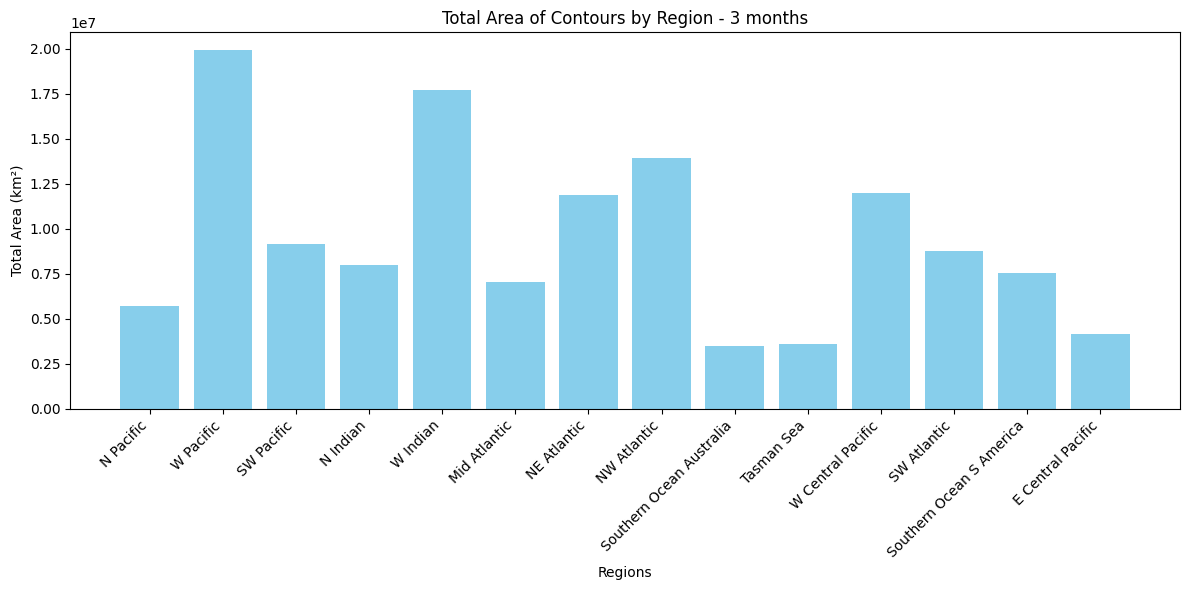

1 month: 76,639,761 km²


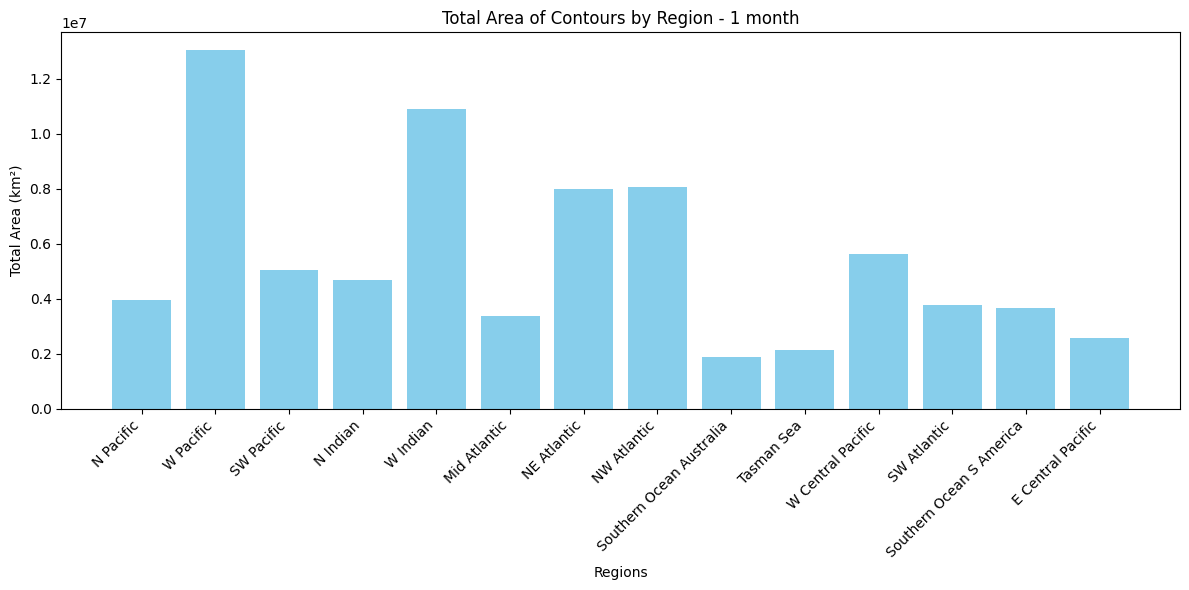

In [7]:
for period_label in PERIOD_ORDER:
    total_area = area_table.loc[period_label].sum()
    print(f"{period_label}: {total_area:,.0f} km²")
    plot_area_bars(
        area_results_by_period[period_label],
        f"Total Area of Contours by Region - {period_label}",
    )


#### initialize final bar plot


In [8]:
regions = watershed_order.copy()
area_12_vals = area_table.loc["12 months"].to_numpy()
area_6_vals = area_table.loc["6 months"].to_numpy()
area_3_vals = area_table.loc["3 months"].to_numpy()
area_1_vals = area_table.loc["1 month"].to_numpy()

area_3_component = np.clip(area_3_vals - area_1_vals, 0, None)
area_6_component = np.clip(area_6_vals - area_3_vals, 0, None)
area_12_component = np.clip(area_12_vals - area_6_vals, 0, None)

stacked_area_table = pd.DataFrame(
    {
        "1 month": area_1_vals,
        "3 months": area_3_component,
        "6 months": area_6_component,
        "12 months": area_12_component,
    },
    index=DISPLAY_LABELS,
)
stacked_area_table


,1 month,3 months,6 months,12 months
N Pacific,3.940888e+06,1.772531e+06,1.624201e+06,2.565926e+06
W Pacific,1.303512e+07,6.871449e+06,6.028262e+06,5.644946e+06
SW Pacific,5.031020e+06,4.098978e+06,3.155131e+06,3.008447e+06
N Indian,4.701193e+06,3.303776e+06,4.289623e+06,3.835380e+06
W Indian,1.089382e+07,6.819536e+06,7.779850e+06,1.688003e+07
Mid Atlantic,3.372058e+06,3.650028e+06,2.528237e+06,1.286038e+06
NE Atlantic,7.986847e+06,3.886358e+06,3.076928e+06,4.516644e+06
NW Atlantic,8.058438e+06,5.886109e+06,7.139064e+06,6.914883e+06
Southern Ocean Australia,1.874649e+06,1.632594e+06,1.726757e+06,3.864060e+06
Tasman Sea,2.135502e+06,1.466298e+06,2.670312e+06,3.298868e+06


#### final bar plot


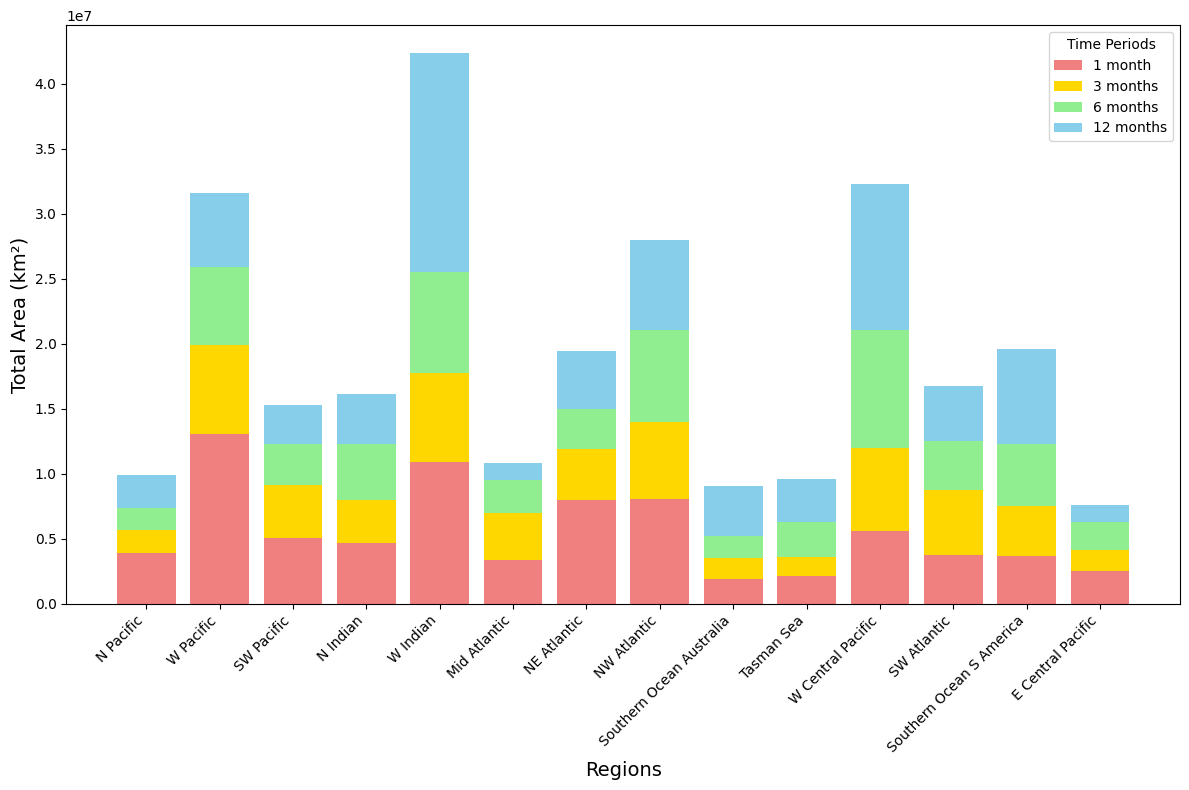

In [9]:
plt.figure(figsize=(12, 8))

plt.bar(DISPLAY_LABELS, area_1_vals, label="1 month", color="lightcoral")
plt.bar(DISPLAY_LABELS, area_3_component, bottom=area_1_vals, label="3 months", color="gold")
plt.bar(
    DISPLAY_LABELS,
    area_6_component,
    bottom=area_1_vals + area_3_component,
    label="6 months",
    color="lightgreen",
)
plt.bar(
    DISPLAY_LABELS,
    area_12_component,
    bottom=area_1_vals + area_3_component + area_6_component,
    label="12 months",
    color="skyblue",
)

plt.xlabel("Regions", fontsize=14)
plt.ylabel("Total Area (km²)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Time Periods")
plt.tight_layout()
plt.show()


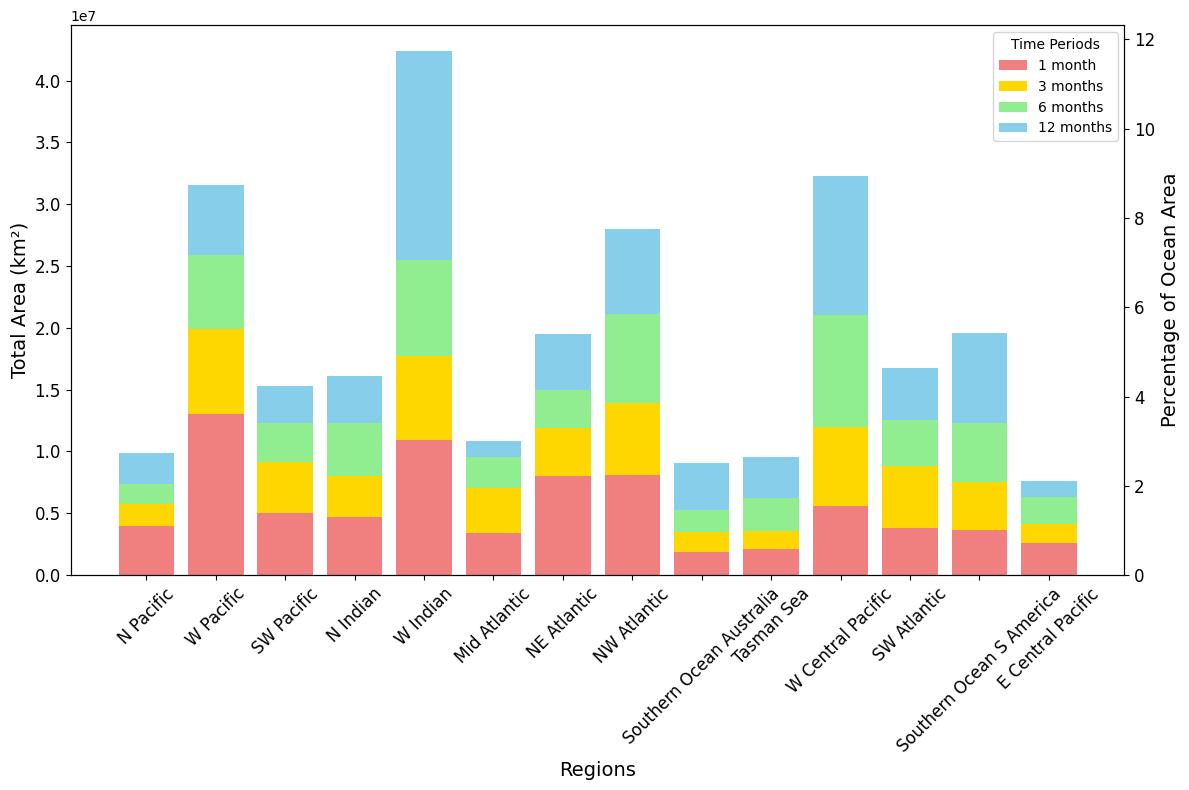

In [ ]:
stacked_totals = area_1_vals + area_3_component + area_6_component + area_12_component
primary_y_max = max(stacked_totals.max() * 1.05, 1)

fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.bar(DISPLAY_LABELS, area_1_vals, label="1 month", color="lightcoral")
ax1.bar(DISPLAY_LABELS, area_3_component, bottom=area_1_vals, label="3 months", color="gold")
ax1.bar(
    DISPLAY_LABELS,
    area_6_component,
    bottom=area_1_vals + area_3_component,
    label="6 months",
    color="lightgreen",
)
ax1.bar(
    DISPLAY_LABELS,
    area_12_component,
    bottom=area_1_vals + area_3_component + area_6_component,
    label="12 months",
    color="skyblue",
)

ax1.set_xlabel("Regions", fontsize=14)
ax1.set_ylabel("Total Area (km²)", fontsize=14)
ax1.tick_params(axis="x", rotation=45, labelsize=12)
ax1.tick_params(axis="y", labelsize=12)
ax1.set_ylim(0, primary_y_max)
ax1.legend(title="Time Periods")

ax2 = ax1.twinx()
ax2.set_ylim(0, primary_y_max / TOTAL_OCEAN_AREA_KM2 * 100)
ax2.set_ylabel("Percentage of Ocean Area", fontsize=14)
ax2.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.savefig("figs/total_watershed_final", dpi=300)
plt.show()


### area verification


In [11]:
def compare_areas_to_ocean(ocean_area, table):
    coverage_pct = (table / ocean_area) * 100
    total_area = table.sum(axis=1)
    total_coverage_pct = (total_area / ocean_area) * 100

    summary = pd.DataFrame(
        {
            "total_area_km2": total_area,
            "pct_ocean_area": total_coverage_pct,
        }
    )
    return coverage_pct, summary

coverage_table, coverage_summary = compare_areas_to_ocean(TOTAL_OCEAN_AREA_KM2, area_table)

print("Percent of ocean area covered by each watershed contour:")
display(coverage_table.round(3))

print("Combined area across all watersheds:")
coverage_summary.round(3)


Percent of ocean area covered by each watershed contour:


,N_Pacific,W_Pacific,SW_Pacific,N_Indian,W_Indian,Mid_Atlantic,NE_Atlantic,NW_Atlantic,Southern_Ocean_Australia,Tasman_Sea,W_Central_Pacific,SW_Atlantic,Southern_Ocean_S_America,E_Central_Pacific
1 month,1.091,3.610,1.393,1.302,3.017,0.934,2.212,2.231,0.519,0.591,1.555,1.045,1.012,0.710
3 months,1.582,5.512,2.528,2.217,4.905,1.944,3.288,3.861,0.971,0.997,3.322,2.433,2.086,1.152
6 months,2.032,7.182,3.402,3.404,7.059,2.645,4.140,5.838,1.449,1.737,5.822,3.470,3.411,1.750
12 months,2.742,8.745,4.235,4.467,11.733,3.001,5.390,7.753,2.519,2.650,8.932,4.634,5.433,2.097


Combined area across all watersheds:


,total_area_km2,pct_ocean_area
1 month,7.663976e+07,21.222
3 months,1.328918e+08,36.799
6 months,1.926287e+08,53.340
12 months,2.684399e+08,74.333


In [12]:
def combined_heatmap(period_label):
    return sum(histograms_by_period[period_label].values())

def plot_combined_heatmap(period_label, percentile=80):
    heatmap_data = combined_heatmap(period_label)
    positive_cells = heatmap_data[heatmap_data > 0]

    if positive_cells.size == 0:
        raise ValueError(f"No populated grid cells found for {period_label}")

    contour_level = float(np.percentile(positive_cells, percentile))

    fig, ax = plt.subplots(figsize=(15, 7))
    mesh = ax.pcolormesh(
        lon_centers,
        lat_centers,
        heatmap_data,
        cmap="viridis",
        shading="auto",
    )
    contour = ax.contour(
        lon_centers,
        lat_centers,
        heatmap_data,
        levels=[contour_level],
        colors="white",
        linewidths=1.5,
    )

    ax.set_xlim(-180, 180)
    ax.set_ylim(-70, 70)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{period_label} Combined Trajectory Density Heatmap")
    plt.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.8, label="Heatmap Density")
    plt.tight_layout()
    plt.show()

    total_area = contour_area_from_segments(contour.allsegs[0]) if contour.allsegs[0] else 0.0
    coverage_percentage = (total_area / TOTAL_OCEAN_AREA_KM2) * 100

    return {
        "area_km2": total_area,
        "coverage_pct": coverage_percentage,
        "contour_level": contour_level,
    }


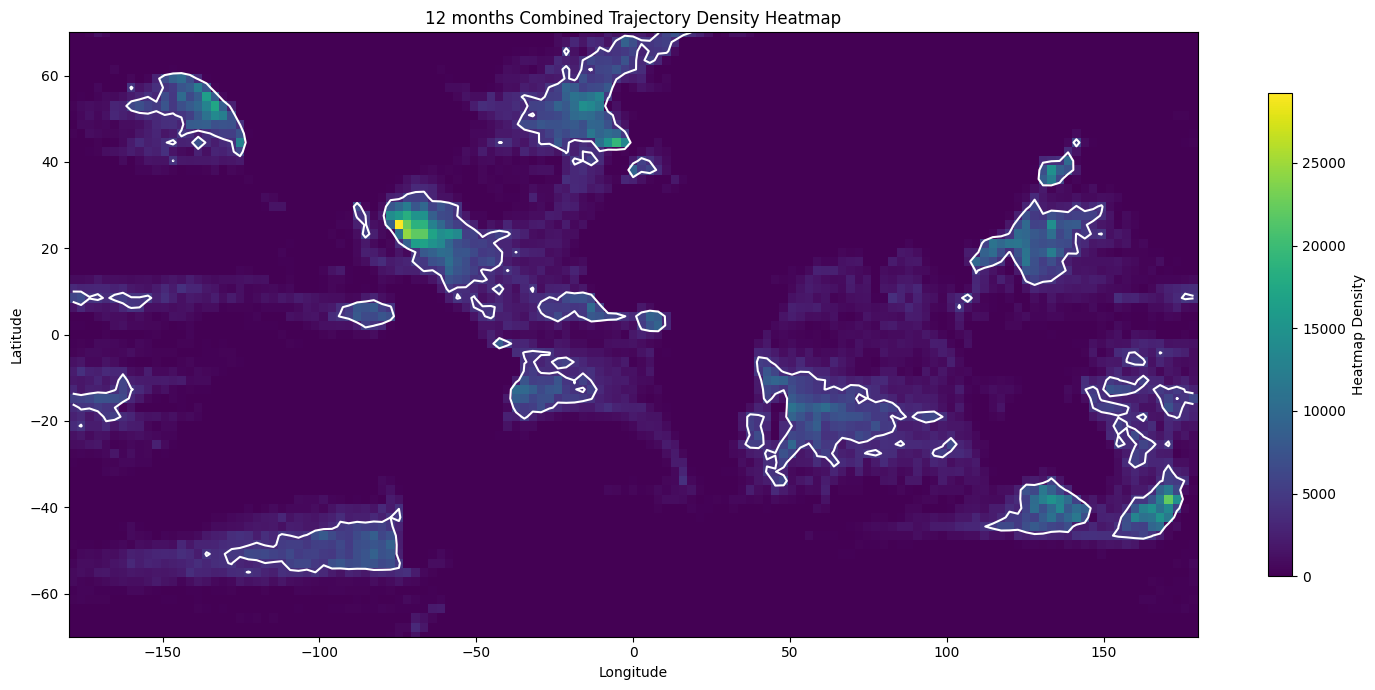

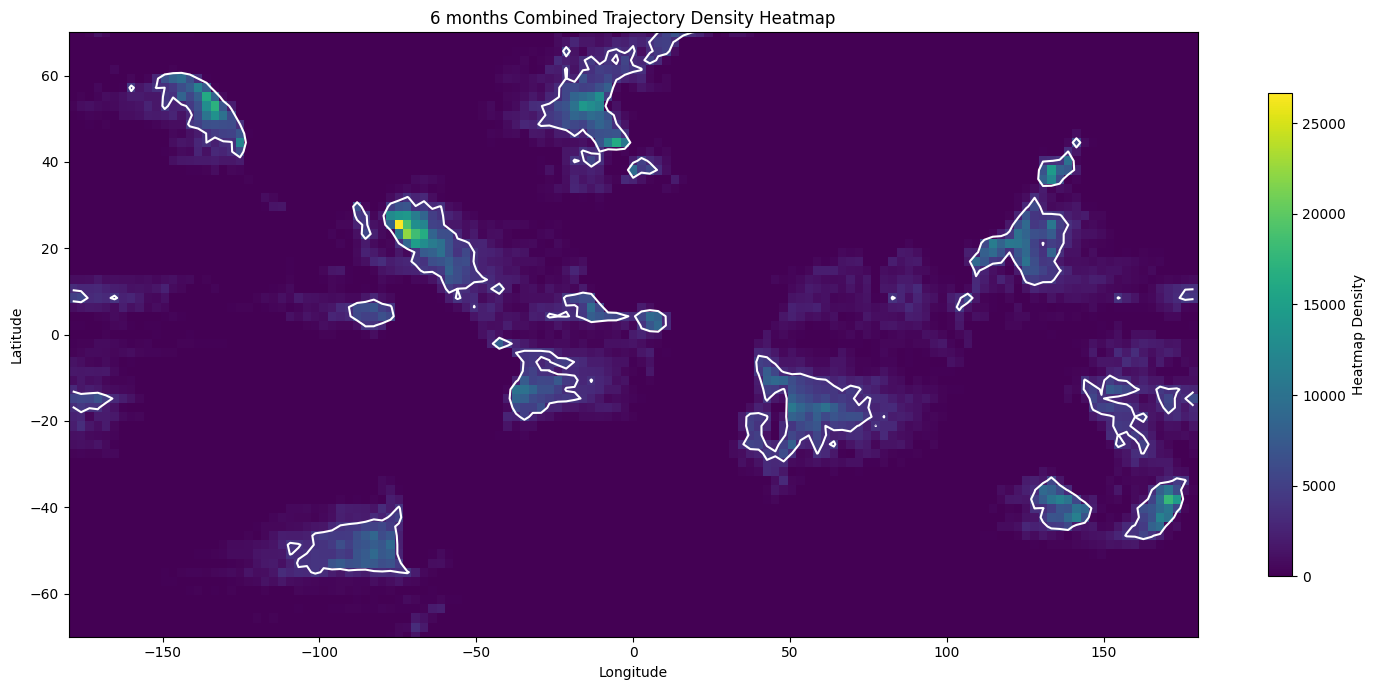

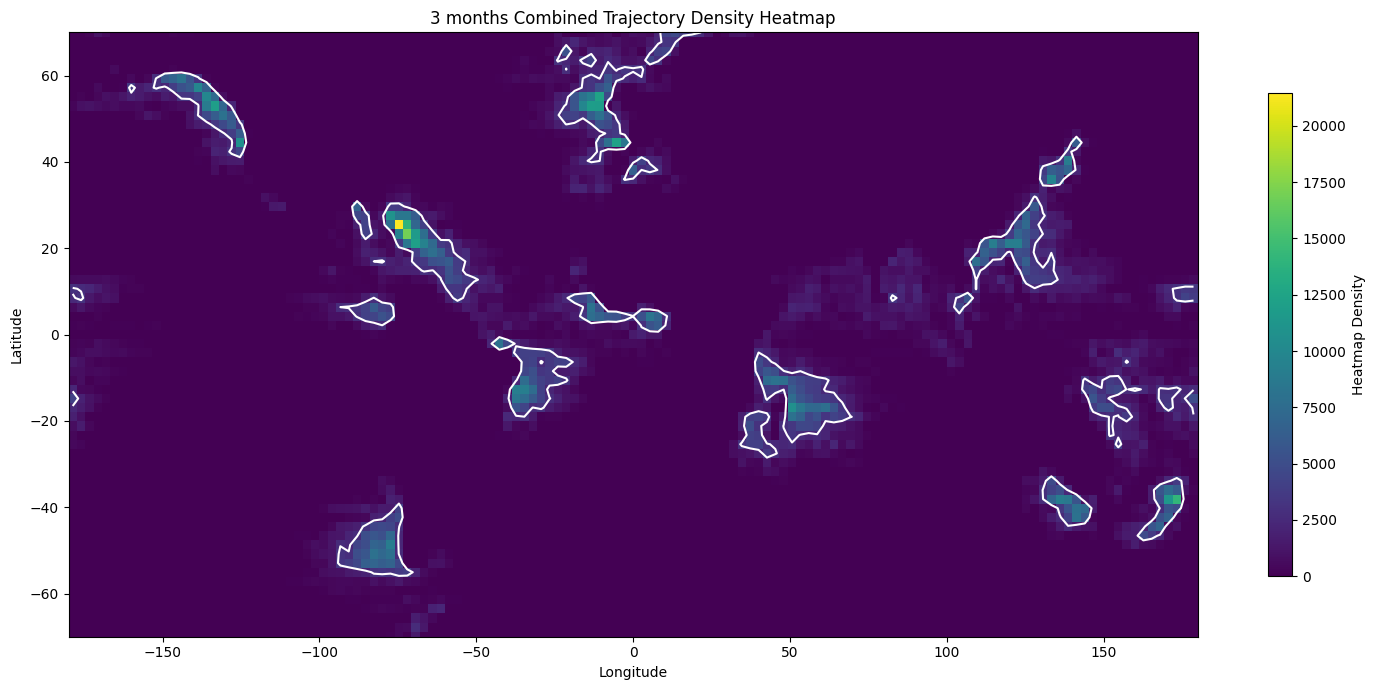

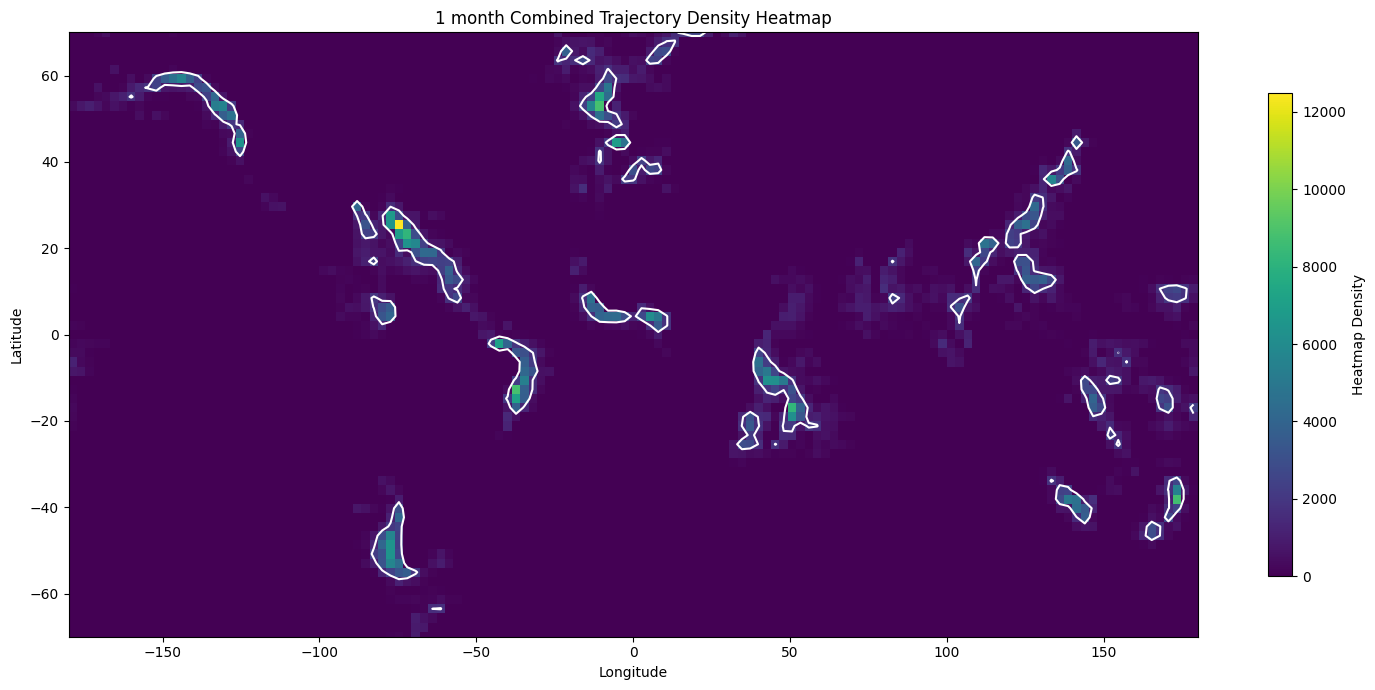

,area_km2,coverage_pct,contour_level
12 months,4.244371e+07,11.753,4093.6
6 months,3.185988e+07,8.822,3570.0
3 months,2.448807e+07,6.781,2710.0
1 month,1.469877e+07,4.070,1645.0


In [13]:
combined_heatmap_summary = pd.DataFrame(
    {
        period_label: plot_combined_heatmap(period_label)
        for period_label in PERIOD_ORDER
    }
).T

combined_heatmap_summary.round(3)
